In [3]:
import pandas as pd

data = pd.read_csv('remoteok_jobs.csv')

df = pd.DataFrame(data)
df.head(10)

,job_title,company_name,location,required_skills,salary,job_category,posting_date
0,Junior Crypto Trader,ATOM PARTNERS LIMITED,🌏 Worldwide,NaN,$50000-70000 / YEAR,Junior Crypto Trader,2026-07-01T15:05:02+00:00
1,Builder Chief,Consultran,🇺🇸 United States,NaN,$80000-120000 / YEAR,Builder Chief,2026-07-05T00:00:08+00:00
2,Senior Software Engineer,Stellar AI,🇪🇺 Europe,NaN,NaN,NaN,NaN
3,Business Analyst,Rotaract Club of NIBM Kandy,🇺🇸 United States,NaN,$80000-150000 / YEAR,Business Analyst,2026-07-05T17:18:41+00:00
4,Innovation,Doshi Group,"Nagpur,",NaN,$80000-150000 / YEAR,Innovation,2026-07-05T12:34:47+00:00
5,Mid Senior AI Cinematic Video Editor,EverAI,🇪🇺 Europe,NaN,$60000-100000 / YEAR,Mid Senior AI Cinematic Video Editor,2026-07-05T00:00:10+00:00
6,Supply Chain Analyst,DIVA,🇨🇦 Canada,NaN,$80000-150000 / YEAR,Supply Chain Analyst,2026-07-05T00:00:00+00:00
7,Junior Front End Developer,PULSEMEDIA (MENA),"الرياض, الرياض الرياض السعودية",NaN,$80000-150000 / YEAR,Junior Front End Developer,2026-07-05T00:00:00+00:00
8,dishwasher,Pür &amp; Simple,🌏 Worldwide,NaN,$80000-150000 / YEAR,dishwasher,2026-07-04T22:40:52+00:00
9,Human Resources Generalist,CoberonChronos,New York City Metropolitan Area,NaN,$80000-150000 / YEAR,Human Resources Generalist,2026-07-04T21:10:36+00:00


3. Problem Statement
The demand for remote jobs has increased significantly in recent years. However, job seekers often
spend considerable time visiting job portals repeatedly to search for suitable opportunities. Since new
jobs are posted frequently, manually tracking these listings is inefficient and time-consuming.
This project aims to automate the process of collecting remote job listings using Python web scraping
techniques. The extracted data can then be analyzed to identify hiring trends, popular job roles,
in-demand technical skills, top recruiting companies, and geographical distribution of remote
opportunities. This enables users to make informed career decisions based on real-time market
insights.

4. Project Objectives
• Automate the extraction of remote job listings.
• Collect job-related information from the website.
• Store the extracted data in CSV or Excel format.
• Perform data cleaning and preprocessing.
• Conduct Exploratory Data Analysis (EDA).
• Visualize hiring trends using charts and graphs.
• Identify the most in-demand skills and job roles.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   job_title        348 non-null    str    
 1   company_name     348 non-null    str    
 2   location         348 non-null    str    
 3   required_skills  0 non-null      float64
 4   salary           345 non-null    str    
 5   job_category     345 non-null    str    
 6   posting_date     345 non-null    str    
dtypes: float64(1), str(6)
memory usage: 19.2 KB


In [6]:
df.shape

(348, 7)

In [7]:
df.tail()

,job_title,company_name,location,required_skills,salary,job_category,posting_date
343,Retail Marketing Coordinator,Crown Affair,New York City Metropolitan Area,NaN,$80000-150000 / YEAR,Retail Marketing Coordinator,2026-06-23T21:57:44+00:00
344,Creative Director,Strange Face,🇬🇧 United Kingdom,NaN,$80000-150000 / YEAR,Creative Director,2026-06-23T20:13:49+00:00
345,Social Media Manager,Strange Face,🇬🇧 United Kingdom,NaN,$80000-150000 / YEAR,Social Media Manager,2026-06-23T20:06:20+00:00
346,Patient Advocate,Cedar,🇺🇸 United States,NaN,$80000-150000 / YEAR,Patient Advocate,2026-06-23T19:53:32+00:00
347,Executive Assistant &amp; HR Administrator,People Architects,🇺🇸 United States,NaN,$80000-150000 / YEAR,Executive Assistant &amp; HR Administrator,2026-06-23T19:39:28+00:00


# 1. Check Missing Values

In [8]:
missing = df.isnull().sum().sort_values(ascending=False)
missing

required_skills    348
salary               3
job_category         3
posting_date         3
location             0
job_title            0
company_name         0
dtype: int64

# 2. Check Duplicate Rows

In [9]:
df.duplicated().sum()

np.int64(1)

* 3. Check Duplicate Columns (Semantic)

Sometimes columns contain identical information.

In [10]:
(df["job_title"] == df["job_category"]).value_counts(dropna=False)

True     345
False      3
Name: count, dtype: int64

# 4. Check Unique Values

Useful for identifying

categorical columns
high-cardinality columns

In [11]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].nunique())



job_title
328

company_name
303

location
47

required_skills
0

salary
9

job_category
325

posting_date
333


* Step 3: Detect Strange Characters

Especially emojis.

In [12]:
df["location"].str.contains(r"[^\x00-\x7F]", regex=True, na=False)

0       True
1       True
2       True
3       True
4      False
       ...  
343    False
344     True
345     True
346     True
347     True
Name: location, Length: 348, dtype: bool

# Step 4: Whitespace Issues

In [13]:
for col in df.select_dtypes(include="object"):
    print(col)

    print(
        (df[col] != df[col].str.strip()).sum()
    )

job_title
0
company_name
0
location
0
salary
3
job_category
3
posting_date
3


C:\Users\Dell\AppData\Local\Temp\ipykernel_24812\1717759699.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


* Step 5: Check Case Inconsistency

Step 6: Length Check

In [16]:
for col in ["job_title", "company_name"]:

    print(col)

    print(df[col].str.len().describe())

job_title
count    348.000000
mean      24.316092
std       14.558560
min        1.000000
25%       14.000000
50%       22.000000
75%       31.000000
max      110.000000
Name: job_title, dtype: float64
company_name
count    348.000000
mean      15.327586
std        9.317124
min        2.000000
25%        9.000000
50%       13.000000
75%       20.000000
max       66.000000
Name: company_name, dtype: float64


In [18]:
df.head()

,job_title,company_name,location,required_skills,salary,job_category,posting_date
0,Junior Crypto Trader,ATOM PARTNERS LIMITED,🌏 Worldwide,NaN,$50000-70000 / YEAR,Junior Crypto Trader,2026-07-01T15:05:02+00:00
1,Builder Chief,Consultran,🇺🇸 United States,NaN,$80000-120000 / YEAR,Builder Chief,2026-07-05T00:00:08+00:00
2,Senior Software Engineer,Stellar AI,🇪🇺 Europe,NaN,NaN,NaN,NaN
3,Business Analyst,Rotaract Club of NIBM Kandy,🇺🇸 United States,NaN,$80000-150000 / YEAR,Business Analyst,2026-07-05T17:18:41+00:00
4,Innovation,Doshi Group,"Nagpur,",NaN,$80000-150000 / YEAR,Innovation,2026-07-05T12:34:47+00:00


In [19]:
df["salary"].describe()

count                      345
unique                       9
top       $80000-150000 / YEAR
freq                       337
Name: salary, dtype: object

Step 9: Missing Pattern

In [21]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.


<Axes: >

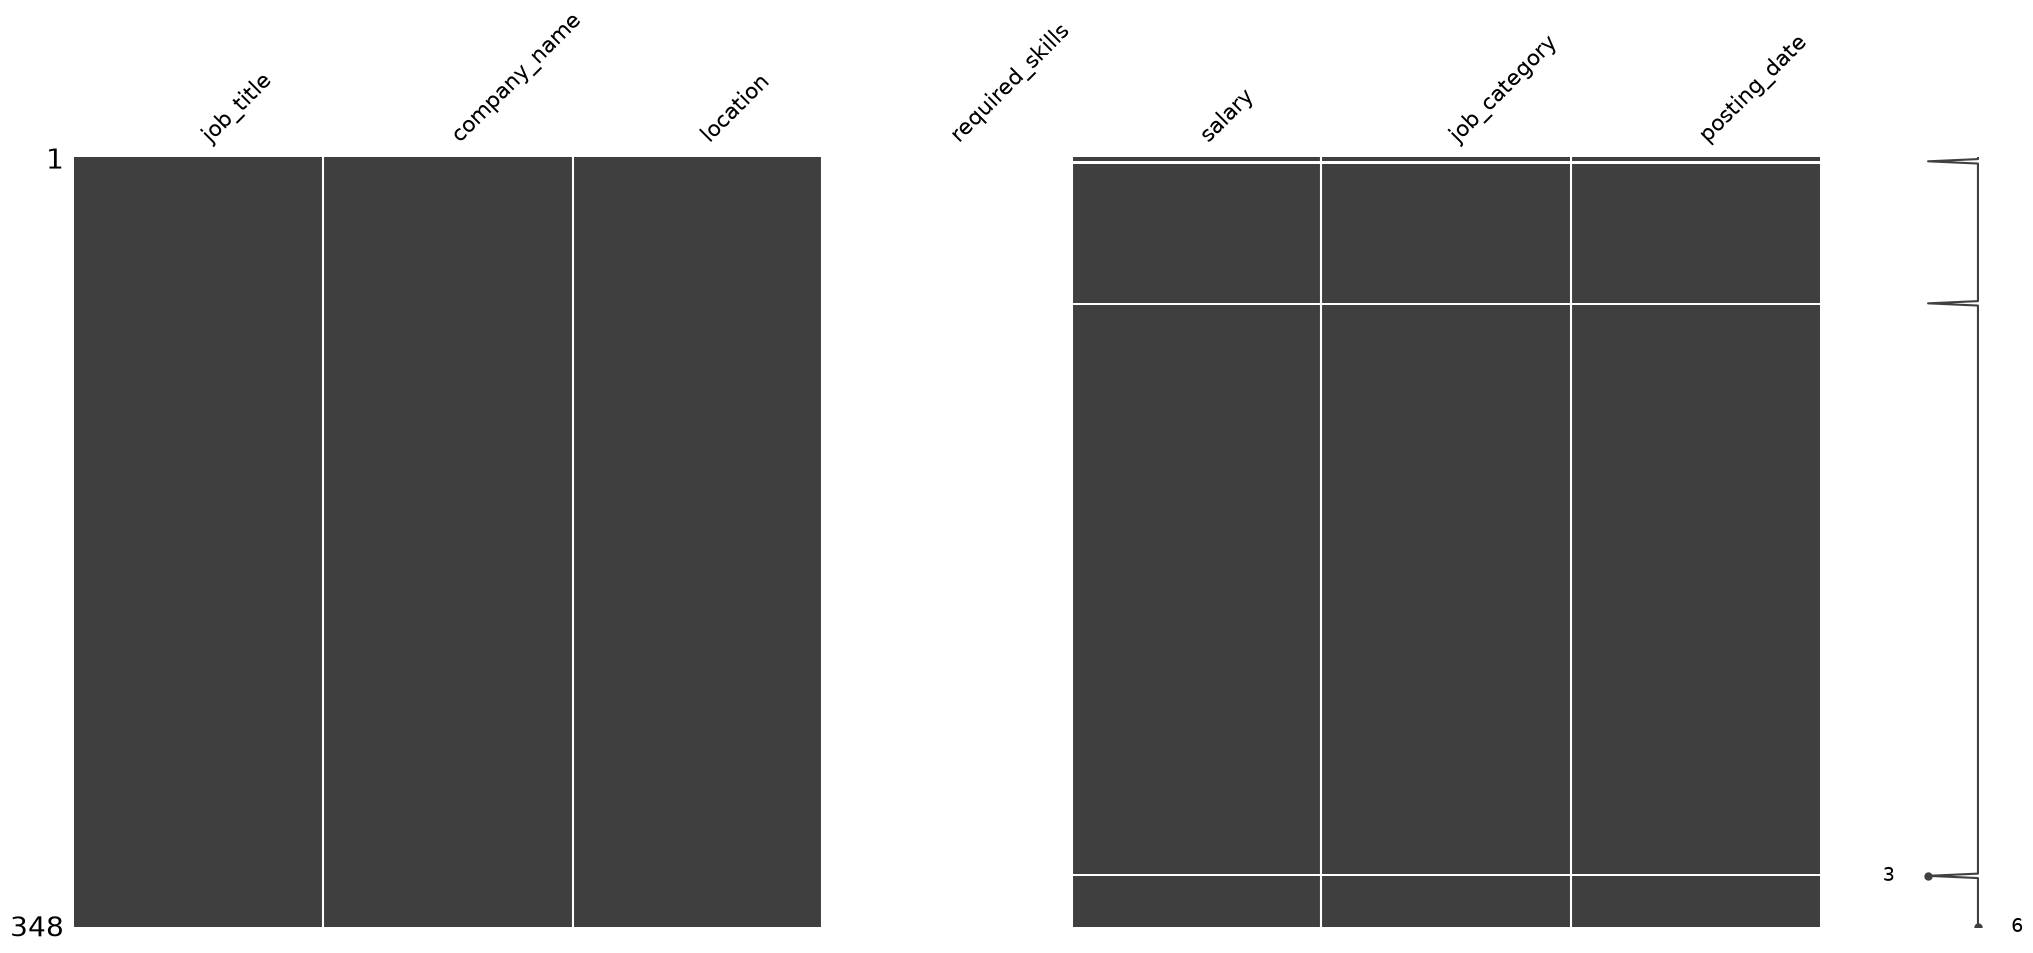

In [22]:
import missingno as msno

msno.matrix(df)

- after seeing what are all the inconsistencies in the data , make a copy of that data
- and always preserve the raw data as it is 



In [23]:
df_clean = df.copy()
df_clean

,job_title,company_name,location,required_skills,salary,job_category,posting_date
0,Junior Crypto Trader,ATOM PARTNERS LIMITED,🌏 Worldwide,NaN,$50000-70000 / YEAR,Junior Crypto Trader,2026-07-01T15:05:02+00:00
1,Builder Chief,Consultran,🇺🇸 United States,NaN,$80000-120000 / YEAR,Builder Chief,2026-07-05T00:00:08+00:00
2,Senior Software Engineer,Stellar AI,🇪🇺 Europe,NaN,NaN,NaN,NaN
3,Business Analyst,Rotaract Club of NIBM Kandy,🇺🇸 United States,NaN,$80000-150000 / YEAR,Business Analyst,2026-07-05T17:18:41+00:00
4,Innovation,Doshi Group,"Nagpur,",NaN,$80000-150000 / YEAR,Innovation,2026-07-05T12:34:47+00:00
...,...,...,...,...,...,...,...
343,Retail Marketing Coordinator,Crown Affair,New York City Metropolitan Area,NaN,$80000-150000 / YEAR,Retail Marketing Coordinator,2026-06-23T21:57:44+00:00
344,Creative Director,Strange Face,🇬🇧 United Kingdom,NaN,$80000-150000 / YEAR,Creative Director,2026-06-23T20:13:49+00:00
345,Social Media Manager,Strange Face,🇬🇧 United Kingdom,NaN,$80000-150000 / YEAR,Social Media Manager,2026-06-23T20:06:20+00:00
346,Patient Advocate,Cedar,🇺🇸 United States,NaN,$80000-150000 / YEAR,Patient Advocate,2026-06-23T19:53:32+00:00


In [24]:
print("Duplicate Rows:", df_clean.duplicated().sum())

Duplicate Rows: 1


In [25]:
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
# cleans that duplicated row

In [ ]:
print("Duplicate Rows:", df_clean.duplicated().sum())
# yes 0 duplicated row

Duplicate Rows: 0


In [27]:
print(df_clean.shape)

(347, 7)


# Step 3: Remove Leading and Trailing Spaces

In [ ]:
object_cols = df_clean.select_dtypes(include="str").columns

for col in object_cols:
    df_clean[col] = df_clean[col].str.strip()


In [30]:
df_clean.head()

,job_title,company_name,location,required_skills,salary,job_category,posting_date
0,Junior Crypto Trader,ATOM PARTNERS LIMITED,🌏 Worldwide,NaN,$50000-70000 / YEAR,Junior Crypto Trader,2026-07-01T15:05:02+00:00
1,Builder Chief,Consultran,🇺🇸 United States,NaN,$80000-120000 / YEAR,Builder Chief,2026-07-05T00:00:08+00:00
2,Senior Software Engineer,Stellar AI,🇪🇺 Europe,NaN,NaN,NaN,NaN
3,Business Analyst,Rotaract Club of NIBM Kandy,🇺🇸 United States,NaN,$80000-150000 / YEAR,Business Analyst,2026-07-05T17:18:41+00:00
4,Innovation,Doshi Group,"Nagpur,",NaN,$80000-150000 / YEAR,Innovation,2026-07-05T12:34:47+00:00


# Step 4: Standardize Missing Values

Many scraped datasets use different placeholders for missing values.

In [32]:
import numpy as np

missing_values = [
    "",
    " ",
    "NA",
    "N/A",
    "None",
    "NULL",
    "null",
    "-",
    "--",
    "Unknown"
]

df_clean.replace(missing_values, np.nan, inplace=True).head()

,job_title,company_name,location,required_skills,salary,job_category,posting_date
0,Junior Crypto Trader,ATOM PARTNERS LIMITED,🌏 Worldwide,NaN,$50000-70000 / YEAR,Junior Crypto Trader,2026-07-01T15:05:02+00:00
1,Builder Chief,Consultran,🇺🇸 United States,NaN,$80000-120000 / YEAR,Builder Chief,2026-07-05T00:00:08+00:00
2,Senior Software Engineer,Stellar AI,🇪🇺 Europe,NaN,NaN,NaN,NaN
3,Business Analyst,Rotaract Club of NIBM Kandy,🇺🇸 United States,NaN,$80000-150000 / YEAR,Business Analyst,2026-07-05T17:18:41+00:00
4,Innovation,Doshi Group,"Nagpur,",NaN,$80000-150000 / YEAR,Innovation,2026-07-05T12:34:47+00:00


In [33]:
df_clean.isnull().sum()

job_title            0
company_name         0
location             0
required_skills    347
salary               3
job_category         3
posting_date         3
dtype: int64

# Step 5: Standardize Text Columns
We don't want

software engineer

Software engineer

SOFTWARE ENGINEER

In [34]:
text_columns = [
    "job_title",
    "company_name",
    "location",
    "job_category"
]

for col in text_columns:
    df_clean[col] = df_clean[col].str.title()

In [35]:
df_clean.head()

,job_title,company_name,location,required_skills,salary,job_category,posting_date
0,Junior Crypto Trader,Atom Partners Limited,🌏 Worldwide,NaN,$50000-70000 / YEAR,Junior Crypto Trader,2026-07-01T15:05:02+00:00
1,Builder Chief,Consultran,🇺🇸 United States,NaN,$80000-120000 / YEAR,Builder Chief,2026-07-05T00:00:08+00:00
2,Senior Software Engineer,Stellar Ai,🇪🇺 Europe,NaN,NaN,NaN,NaN
3,Business Analyst,Rotaract Club Of Nibm Kandy,🇺🇸 United States,NaN,$80000-150000 / YEAR,Business Analyst,2026-07-05T17:18:41+00:00
4,Innovation,Doshi Group,"Nagpur,",NaN,$80000-150000 / YEAR,Innovation,2026-07-05T12:34:47+00:00


# Step 6: Clean Location Column

Current examples
🌏 Worldwide

🇺🇸 United States

🇪🇺 Europe

Nagpur,

Remote (US)

In [39]:
import re

def remove_emoji(text):

    if pd.isna(text):
        return text

    return re.sub(r"[^\x00-\x7F]+", "", text)

df_clean["location"] = df_clean["location"].apply(remove_emoji)
df_clean['location'].head()

0         Worldwide
1     United States
2            Europe
3     United States
4           Nagpur,
Name: location, dtype: str

In [40]:
df_clean["location"] = (        # clean extra spaces also
    df_clean["location"]                             
    .str.replace(",", "", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df_clean['location'].head()      

0        Worldwide
1    United States
2           Europe
3    United States
4           Nagpur
Name: location, dtype: str

In [41]:
location_mapping = {

    "Us": "United States",
    "Usa": "United States",
    "Uk": "United Kingdom",

    "Remote Worldwide": "Worldwide",
    "Global": "Worldwide",

    "Remote": "Remote"
}

df_clean["location"] = df_clean["location"].replace(location_mapping)
df_clean["location"].value_counts().head(30)

location
Worldwide                            131
United States                         73
United Kingdom                        26
India                                 13
Canada                                12
                                      11
Brazil                                11
Australia                              7
Spain                                  6
Peru                                   6
Probably Worldwide                     5
New York City Metropolitan Area        4
Portugal                               4
Europe                                 3
Hong Kong                              3
Argentina                              3
Jamaica                                2
Indonesia                              2
Nagpur                                 1
Latin America                          1
Torino Torino Piemonte Italia          1
Africa                                 1
El Salvador                            1
Laos                                   1
Asia   

# Step 8: Clean Company Names

In [43]:
df_clean["company_name"] = (
    df_clean["company_name"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
df['company_name'].head()

0          ATOM PARTNERS LIMITED
1                     Consultran
2                     Stellar AI
3    Rotaract Club of NIBM Kandy
4                    Doshi Group
Name: company_name, dtype: str

# Step 9: Drop Redundant Columns

Earlier we checked whether

In [44]:
# job_title == job_category

match_percentage = (
    (df_clean["job_title"] == df_clean["job_category"]).mean()
) * 100

print(match_percentage)


99.13544668587896


In [45]:
df_clean.drop(columns=["job_category"], inplace=True)

In [46]:
df_clean.head()

,job_title,company_name,location,required_skills,salary,posting_date
0,Junior Crypto Trader,Atom Partners Limited,Worldwide,NaN,$50000-70000 / YEAR,2026-07-01T15:05:02+00:00
1,Builder Chief,Consultran,United States,NaN,$80000-120000 / YEAR,2026-07-05T00:00:08+00:00
2,Senior Software Engineer,Stellar Ai,Europe,NaN,NaN,NaN
3,Business Analyst,Rotaract Club Of Nibm Kandy,United States,NaN,$80000-150000 / YEAR,2026-07-05T17:18:41+00:00
4,Innovation,Doshi Group,Nagpur,NaN,$80000-150000 / YEAR,2026-07-05T12:34:47+00:00


# Step 10: Convert Posting Date

In [48]:
df_clean["posting_date"] = pd.to_datetime(
    df_clean["posting_date"],
    errors="coerce"
)

In [49]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   job_title        347 non-null    str                
 1   company_name     347 non-null    str                
 2   location         347 non-null    str                
 3   required_skills  0 non-null      float64            
 4   salary           344 non-null    str                
 5   posting_date     344 non-null    datetime64[us, UTC]
dtypes: datetime64[us, UTC](1), float64(1), str(4)
memory usage: 16.4 KB


In [50]:
# extract useful features and whcihare used in machine learning

df_clean["posting_year"] = df_clean["posting_date"].dt.year

df_clean["posting_month"] = df_clean["posting_date"].dt.month

df_clean["posting_day"] = df_clean["posting_date"].dt.day

df_clean["posting_weekday"] = (
    df_clean["posting_date"].dt.day_name()
)

In [ ]:
df_clean.head()

,job_title,company_name,location,required_skills,salary,posting_date,posting_year,posting_month,posting_day,posting_weekday
0,Junior Crypto Trader,Atom Partners Limited,Worldwide,NaN,$50000-70000 / YEAR,2026-07-01 15:05:02+00:00,2026.0,7.0,1.0,Wednesday
1,Builder Chief,Consultran,United States,NaN,$80000-120000 / YEAR,2026-07-05 00:00:08+00:00,2026.0,7.0,5.0,Sunday
2,Senior Software Engineer,Stellar Ai,Europe,NaN,NaN,NaT,NaN,NaN,NaN,NaN
3,Business Analyst,Rotaract Club Of Nibm Kandy,United States,NaN,$80000-150000 / YEAR,2026-07-05 17:18:41+00:00,2026.0,7.0,5.0,Sunday
4,Innovation,Doshi Group,Nagpur,NaN,$80000-150000 / YEAR,2026-07-05 12:34:47+00:00,2026.0,7.0,5.0,Sunday


In [56]:
df_clean.drop(columns=["required_skills"], inplace=True)
df_clean.head()

,job_title,company_name,location,salary,posting_date,posting_year,posting_month,posting_day,posting_weekday
0,Junior Crypto Trader,Atom Partners Limited,Worldwide,$50000-70000 / YEAR,2026-07-01 15:05:02+00:00,2026.0,7.0,1.0,Wednesday
1,Builder Chief,Consultran,United States,$80000-120000 / YEAR,2026-07-05 00:00:08+00:00,2026.0,7.0,5.0,Sunday
2,Senior Software Engineer,Stellar Ai,Europe,NaN,NaT,NaN,NaN,NaN,NaN
3,Business Analyst,Rotaract Club Of Nibm Kandy,United States,$80000-150000 / YEAR,2026-07-05 17:18:41+00:00,2026.0,7.0,5.0,Sunday
4,Innovation,Doshi Group,Nagpur,$80000-150000 / YEAR,2026-07-05 12:34:47+00:00,2026.0,7.0,5.0,Sunday


In [58]:
# rename the column
df_clean.rename(columns={"salary": "salary_per_year"}, inplace=True)

Step 2: Extract the average salary

Your salaries are in the format:

In [59]:
import pandas as pd
import numpy as np

# Extract min and max salary
salary_range = df_clean["salary_per_year"].str.extract(r"\$?(\d+)-(\d+)")

salary_range = salary_range.astype(float)

# Compute average salary
df_clean["salary_per_year"] = salary_range.mean(axis=1)


In [60]:
median_salary = df_clean["salary_per_year"].median()

df_clean["salary_per_year"] = df_clean["salary_per_year"].fillna(median_salary)


In [61]:
df_clean["salary_per_year"] = df_clean["salary_per_year"].astype(int)

In [62]:
df_clean["salary_per_year"].describe()

count       347.000000
mean     115309.798271
std       15031.080198
min       35000.000000
25%      115000.000000
50%      115000.000000
75%      115000.000000
max      350000.000000
Name: salary_per_year, dtype: float64

In [63]:
df_clean.head()

,job_title,company_name,location,salary_per_year,posting_date,posting_year,posting_month,posting_day,posting_weekday
0,Junior Crypto Trader,Atom Partners Limited,Worldwide,60000,2026-07-01 15:05:02+00:00,2026.0,7.0,1.0,Wednesday
1,Builder Chief,Consultran,United States,100000,2026-07-05 00:00:08+00:00,2026.0,7.0,5.0,Sunday
2,Senior Software Engineer,Stellar Ai,Europe,115000,NaT,NaN,NaN,NaN,NaN
3,Business Analyst,Rotaract Club Of Nibm Kandy,United States,115000,2026-07-05 17:18:41+00:00,2026.0,7.0,5.0,Sunday
4,Innovation,Doshi Group,Nagpur,115000,2026-07-05 12:34:47+00:00,2026.0,7.0,5.0,Sunday


In [64]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   job_title        347 non-null    str                
 1   company_name     347 non-null    str                
 2   location         347 non-null    str                
 3   salary_per_year  347 non-null    int64              
 4   posting_date     344 non-null    datetime64[us, UTC]
 5   posting_year     344 non-null    float64            
 6   posting_month    344 non-null    float64            
 7   posting_day      344 non-null    float64            
 8   posting_weekday  344 non-null    str                
dtypes: datetime64[us, UTC](1), float64(3), int64(1), str(4)
memory usage: 24.5 KB


ption 1 (Recommended): Drop those rows

If the posting date is an important feature for your ML model:

In [65]:
df_clean = df_clean.dropna(subset=["posting_date"]).reset_index(drop=True)

df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   job_title        344 non-null    str                
 1   company_name     344 non-null    str                
 2   location         344 non-null    str                
 3   salary_per_year  344 non-null    int64              
 4   posting_date     344 non-null    datetime64[us, UTC]
 5   posting_year     344 non-null    float64            
 6   posting_month    344 non-null    float64            
 7   posting_day      344 non-null    float64            
 8   posting_weekday  344 non-null    str                
dtypes: datetime64[us, UTC](1), float64(3), int64(1), str(4)
memory usage: 24.3 KB


# Conduct Exploratory Data Analysis (EDA).

for this dataset this would be the steps to be fallowed 

| Step | Analysis                               | Purpose                                        |
| ---- | -------------------------------------- | ---------------------------------------------- |
| 1    | Dataset shape, dtypes, summary         | Final quality check                            |
| 2    | Salary distribution                    | Check skewness and outliers                    |
| 3    | Top 10 job titles                      | Identify common roles                          |
| 4    | Top 10 companies                       | Identify major employers                       |
| 5    | Job locations                          | Geographic distribution                        |
| 6    | Jobs by weekday                        | Temporal patterns                              |
| 7    | Jobs by month                          | Posting trends                                 |
| 8    | Salary by location                     | Compare compensation across regions            |
| 9    | Salary by job title                    | Identify highest-paying roles                  |
| 10   | Correlation heatmap (numeric features) | Detect relationships between numeric variables |


1. Shape of the dataset

In [66]:
print(f"Rows    : {df_clean.shape[0]}")
print(f"Columns : {df_clean.shape[1]}")

Rows    : 344
Columns : 9


In [67]:
df_clean.dtypes

job_title                          str
company_name                       str
location                           str
salary_per_year                  int64
posting_date       datetime64[us, UTC]
posting_year                   float64
posting_month                  float64
posting_day                    float64
posting_weekday                    str
dtype: object

3. Missing Values

Even after cleaning, verify.

In [68]:
missing = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Percentage": round(df_clean.isnull().mean()*100,2)
})

missing

,Missing Values,Percentage
job_title,0,0.0
company_name,0,0.0
location,0,0.0
salary_per_year,0,0.0
posting_date,0,0.0
posting_year,0,0.0
posting_month,0,0.0
posting_day,0,0.0
posting_weekday,0,0.0


4. Statistical Summary (Numerical)

In [69]:
df_clean.describe()

,salary_per_year,posting_year,posting_month,posting_day
count,344.000000,344.0,344.000000,344.000000
mean,115312.500000,2026.0,6.313953,18.773256
std,15096.642634,0.0,0.464774,11.311945
min,35000.000000,2026.0,6.000000,1.000000
25%,115000.000000,2026.0,6.000000,3.000000
50%,115000.000000,2026.0,6.000000,25.000000
75%,115000.000000,2026.0,7.000000,26.000000
max,350000.000000,2026.0,7.000000,30.000000


In [70]:
df_clean.describe(include="object")   # categorical statistical summary

C:\Users\Dell\AppData\Local\Temp\ipykernel_24812\78994244.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_clean.describe(include="object")   # categorical statistical summary


,job_title,company_name,location,posting_weekday
count,344,344,344,344
unique,324,301,42,7
top,Freelance Designer,Recruit Lytics Hiring,Worldwide,Friday
freq,5,7,131,90


* salary EDA 

In [72]:
# Check Skewness

print("Skewness:", df_clean["salary_per_year"].skew())

Skewness: 11.065367988848584


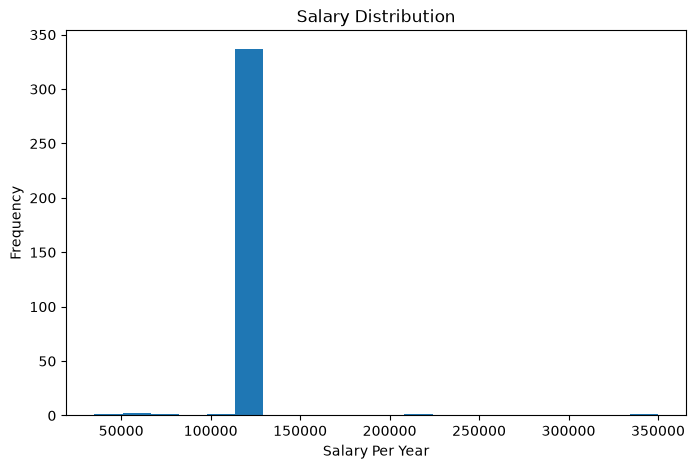

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_clean["salary_per_year"], bins=20)

plt.title("Salary Distribution")
plt.xlabel("Salary Per Year")
plt.ylabel("Frequency")

plt.show()

In [75]:
df_clean["salary_per_year"].value_counts().head(10)

salary_per_year
115000    336
60000       1
100000      1
80000       1
212500      1
35000       1
65000       1
125000      1
350000      1
Name: count, dtype: int64

Box Plot (Outlier Detection)

C:\Users\Dell\AppData\Local\Temp\ipykernel_24812\3584686953.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_clean["salary_per_year"], vert=False)


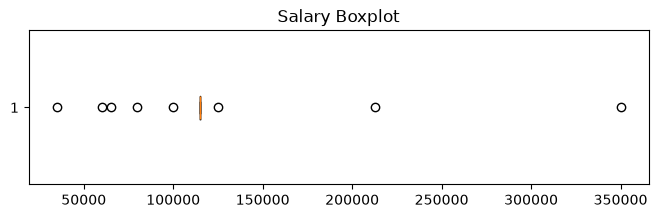

In [74]:
plt.figure(figsize=(8,2))

plt.boxplot(df_clean["salary_per_year"], vert=False)

plt.title("Salary Boxplot")

plt.show()

In [ ]:
# as we see that salary column is fully skewed the reason is , initially we had a 50 columns with salaries and other 200 columns
# without any salary as NAN
# we have done the median imputations that skewed the entire salary column , 
# so we haev to take decision to get the salary column some how 
# or else drop the column of the salary and continue the furter distribution



In [78]:
df_clean.drop(columns=["salary_per_year"], inplace=True)

In [79]:
df_clean.head()

,job_title,company_name,location,posting_date,posting_year,posting_month,posting_day,posting_weekday
0,Junior Crypto Trader,Atom Partners Limited,Worldwide,2026-07-01 15:05:02+00:00,2026.0,7.0,1.0,Wednesday
1,Builder Chief,Consultran,United States,2026-07-05 00:00:08+00:00,2026.0,7.0,5.0,Sunday
2,Business Analyst,Rotaract Club Of Nibm Kandy,United States,2026-07-05 17:18:41+00:00,2026.0,7.0,5.0,Sunday
3,Innovation,Doshi Group,Nagpur,2026-07-05 12:34:47+00:00,2026.0,7.0,5.0,Sunday
4,Mid Senior Ai Cinematic Video Editor,Everai,Europe,2026-07-05 00:00:10+00:00,2026.0,7.0,5.0,Sunday


In [81]:
df_clean = df_clean.dropna(subset=["posting_date"]).reset_index(drop=True)

df_clean["posting_year"] = df_clean["posting_year"].astype(int)
df_clean["posting_month"] = df_clean["posting_month"].astype(int)
df_clean["posting_day"] = df_clean["posting_day"].astype(int)
df_clean.head()

,job_title,company_name,location,posting_date,posting_year,posting_month,posting_day,posting_weekday
0,Junior Crypto Trader,Atom Partners Limited,Worldwide,2026-07-01 15:05:02+00:00,2026,7,1,Wednesday
1,Builder Chief,Consultran,United States,2026-07-05 00:00:08+00:00,2026,7,5,Sunday
2,Business Analyst,Rotaract Club Of Nibm Kandy,United States,2026-07-05 17:18:41+00:00,2026,7,5,Sunday
3,Innovation,Doshi Group,Nagpur,2026-07-05 12:34:47+00:00,2026,7,5,Sunday
4,Mid Senior Ai Cinematic Video Editor,Everai,Europe,2026-07-05 00:00:10+00:00,2026,7,5,Sunday


* visualization

1. Hiring Trend Over Time ⭐⭐⭐⭐⭐

Question answered:

Are job postings increasing or decreasing over time?

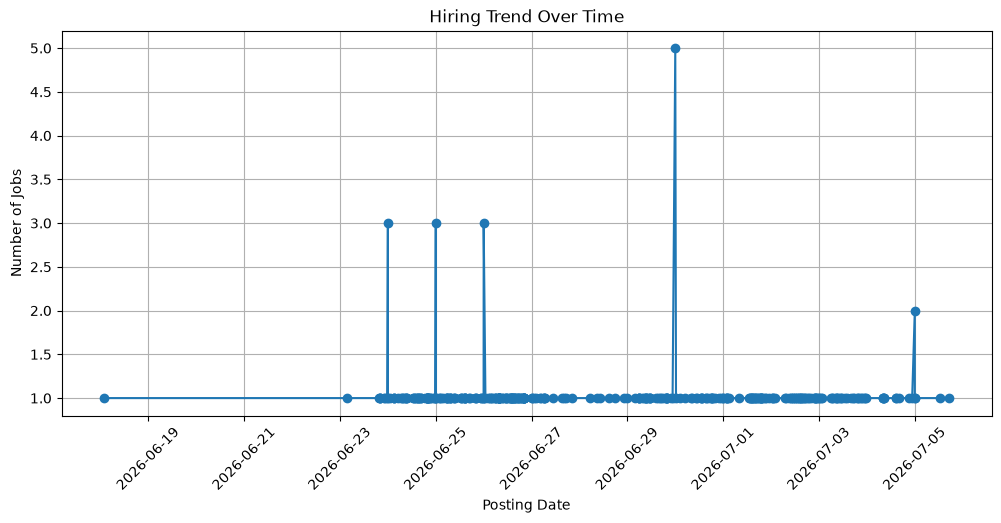

In [82]:
jobs_per_date = (
    df_clean.groupby("posting_date")
            .size()
            .reset_index(name="count")
)

plt.figure(figsize=(12,5))
plt.plot(jobs_per_date["posting_date"], jobs_per_date["count"], marker="o")

plt.title("Hiring Trend Over Time")
plt.xlabel("Posting Date")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

Jobs Posted by Month ⭐⭐⭐⭐

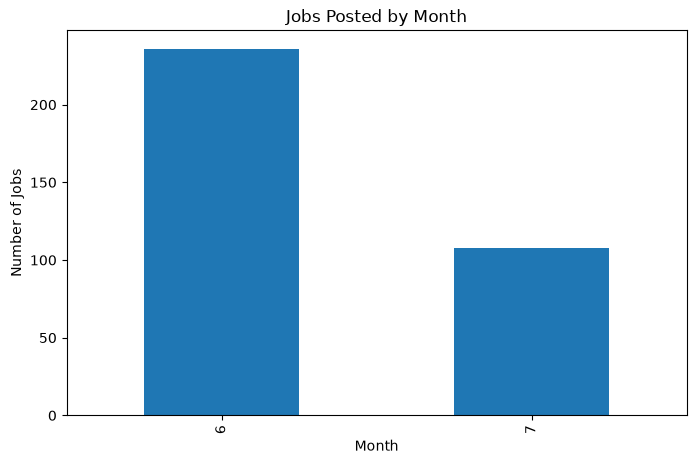

In [83]:
month_counts = (
    df_clean["posting_month"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))
month_counts.plot(kind="bar")

plt.title("Jobs Posted by Month")
plt.xlabel("Month")
plt.ylabel("Number of Jobs")

plt.show()

Top 10 Job Titles ⭐⭐⭐⭐⭐

Probably the most informative chart.

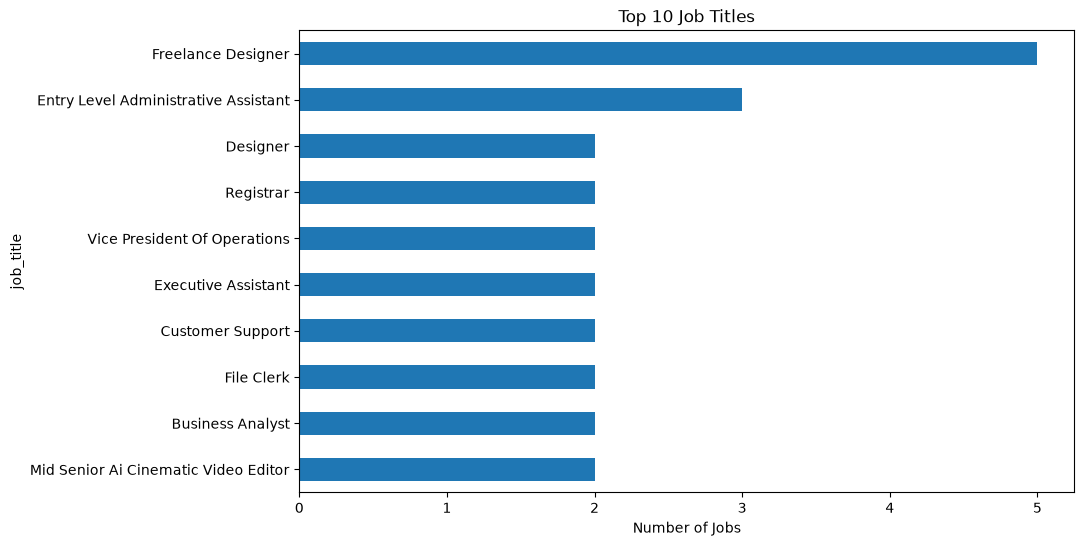

In [84]:
top_jobs = (
    df_clean["job_title"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

top_jobs.sort_values().plot(kind="barh")

plt.title("Top 10 Job Titles")
plt.xlabel("Number of Jobs")

plt.show()

Top Hiring Companies ⭐⭐⭐⭐⭐

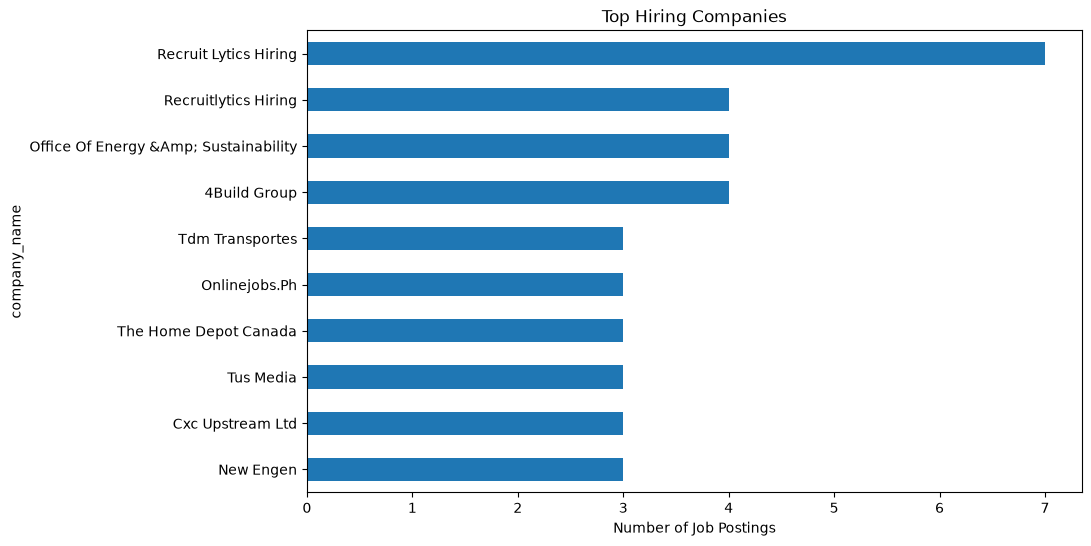

In [85]:
top_companies = (
    df_clean["company_name"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

top_companies.sort_values().plot(kind="barh")

plt.title("Top Hiring Companies")
plt.xlabel("Number of Job Postings")

plt.show()

Job Locations ⭐⭐⭐⭐⭐

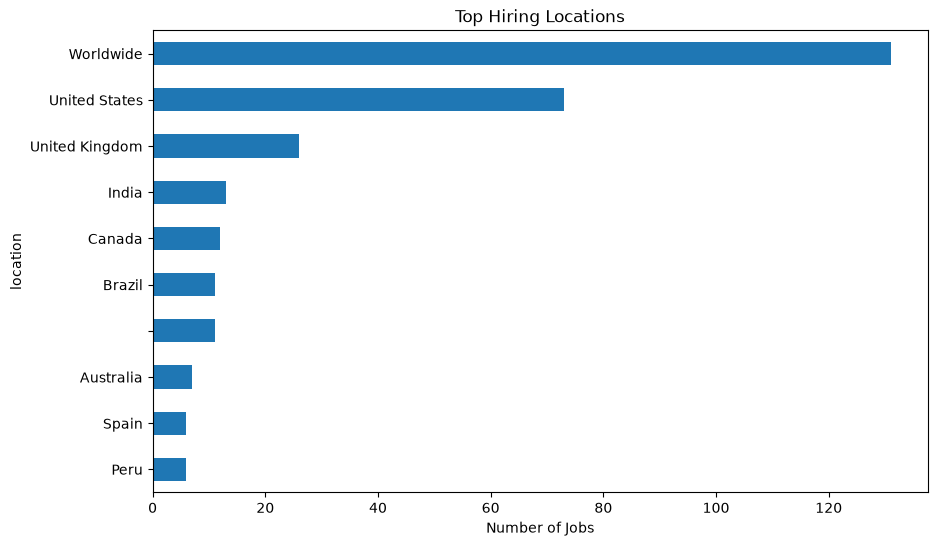

In [86]:
top_locations = (
    df_clean["location"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

top_locations.sort_values().plot(kind="barh")

plt.title("Top Hiring Locations")
plt.xlabel("Number of Jobs")

plt.show()

Jobs per Company (Distribution)

In [87]:
company_counts = df_clean["company_name"].value_counts()

company_counts.describe()

count    301.000000
mean       1.142857
std        0.574042
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        7.000000
Name: count, dtype: float64

Identify the most in-demand skills and job roles.

# no skill column lets see about jobroles which are in demand

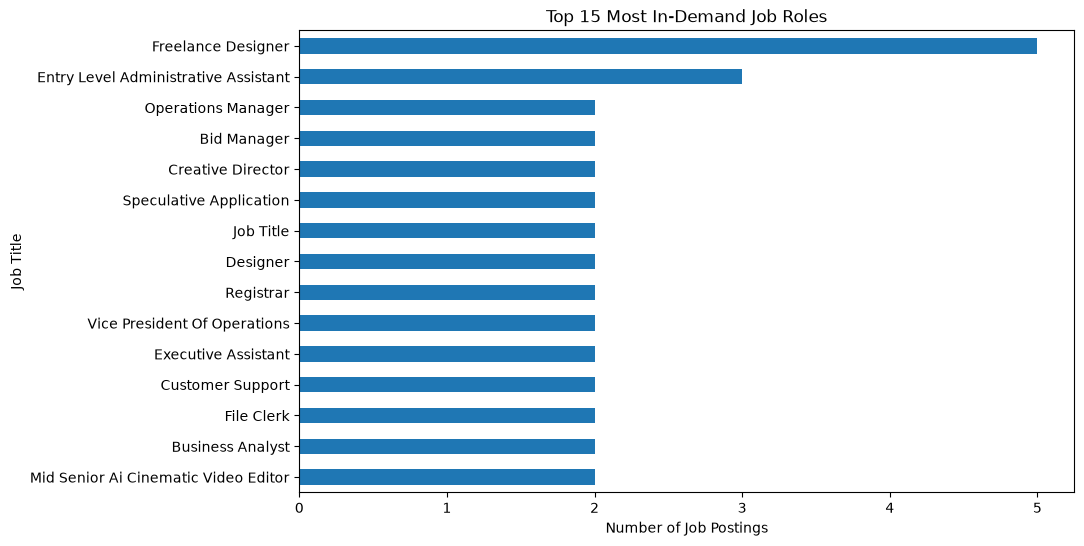

In [88]:
top_roles = (
    df_clean["job_title"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10,6))

top_roles.sort_values().plot(kind="barh")

plt.title("Top 15 Most In-Demand Job Roles")
plt.xlabel("Number of Job Postings")
plt.ylabel("Job Title")

plt.show()